In [59]:
#### importando modulos
import os
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display & plotting options
pd.set_option("display.float_format", "{:.4f}".format)
sns.set(style="whitegrid")

### Paso 2: Coleccionar datos

Se utilizaran laas siguientes acciones del S&P 500:
* TSLA
* AMZN
* MSFT
* NVDA
* GOOGL
* META
* AAPL

In [60]:
#### Funcion para descargar datos
def descargar(tickers: list[str]) -> pd.DataFrame:
    """
    Descarga los datos necesarios de YFinance API

    tickers: lista de las acciones deseadas
    """

    data = yf.download(tickers, start='2000-01-01')

    ### Caso 1: Dataframe con Multiple Indices
    if isinstance(data.columns, pd.MultiIndex):
        # pd.MultiIndex = True cuando hay multiple niveles de columnas
        if "Adj Close" in data.columns.levels[0]:   #Evidencia de multiple niveles
            return data.xs("Adj Close", axis=1, level=0)
                # pd.xs = saca un cross-section de un DF
        else: return data.xs("Close", axis=1, level=0)

    ### Caso 2: Dataframe con solo un Indice
    else:
        if "Adj Close" in data.columns: # No hay multiple niveles
            return data["Adj Close"]
        else: return data["Close"]
    

In [63]:
### Descargando y Guardando datos
tickers = ["TSLA", "AMZN", "MSFT", "NVDA", "GOOGL", "META", "AAPL"]
filepath = os.path.join('Datos', 'datos_crudos.csv')

if os.path.isfile(filepath):
    df_crudo = pd.read_csv(filepath, index_col='Date')
else:
    df_crudo = descargar(tickers)
    df_crudo.to_csv(filepath, index=True, encoding='utf-8')

### Paso 3: Preparar y Limpiar datos

Los siguiente se hara:
* Ver cuantos datos tienen NA
* Ver cuantos duplicados hay

In [76]:
#### Analizando NAs
### Analisis en ambos ejes
print(df_crudo.shape)
# display(df_crudo.isna().sum(axis=0))    # Cada accion
# display(df_crudo.isna().sum(axis=1))    # Cada dia

ds_nas = df_crudo.isna().sum(axis=0)
ds_empresas_con_na = ds_nas[ds_nas > 0]
lista_empresas_na = ds_empresas_con_na.index.to_list()
# print(lista_empresas_na)

### Revsando el ultimo indice de NA
    # Como son fechas, sabemos que los NAs son secuenciales
for empresa in lista_empresas_na:
    print(f'{empresa} - {df_crudo[empresa].first_valid_index()}')

### Manera rapida
df_sin_na = df_crudo.dropna(axis=0, how='any')
print(df_sin_na.iloc[0].name)
print(df_sin_na.shape)


(6676, 7)
GOOGL - 2004-08-19
META - 2012-05-18
TSLA - 2010-06-29
2012-05-18
(3562, 7)


<Figure size 1200x800 with 0 Axes>

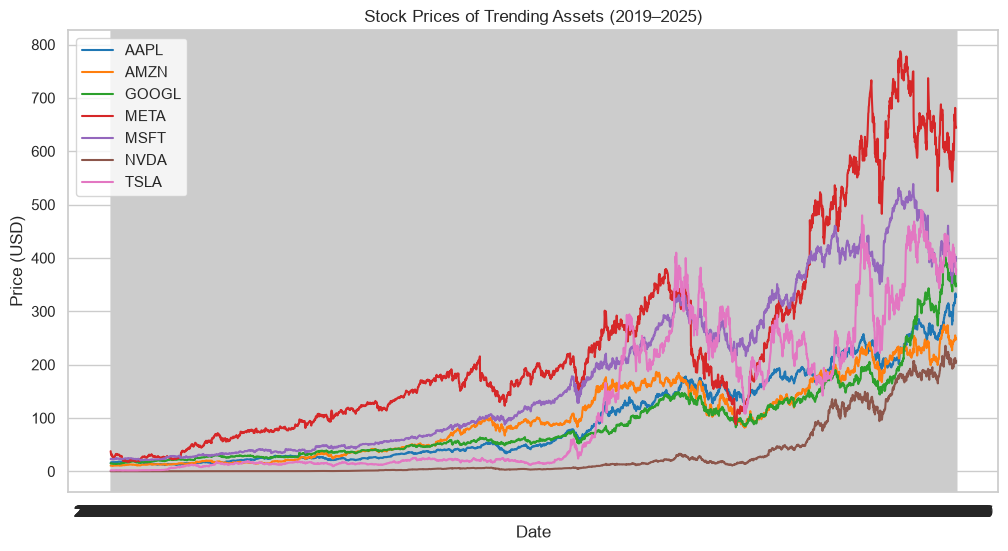

In [77]:
plt.figure(figsize=(12, 8))
# Pick a clear color palette
colors = sns.color_palette("tab10", n_colors=len(df_sin_na.columns))

plt.figure(figsize=(12,6))
for i, ticker in enumerate(df_sin_na.columns):
    plt.plot(df_sin_na.index, df_sin_na[ticker], label=ticker, color=colors[i])

plt.title("Stock Prices of Trending Assets (2019–2025)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()